## From TT optimized models, can simulate and visualize different spiking neural datasets

* need to match these w the parameters in real-life experiments

In [4]:
TT_NODE = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"
TT_gNODE = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True"
TT_nGRU = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2/max_epochs=1500_weight_decay=1.00E-04_learning_rate=1.00E-04_noise=5.00E-04_seed=0_latent_size=128_delta_t=1.00E-02_latent_ic_var=5.00E-03_l2_wt=1.00E-05_noise_level=5.00E-03"

node_sim_data = "/scratch/gpfs/ad2002/content/datasets/dt/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

# currently have heldin_50_heldout_10_obs_noise_pseudoPoisson_dispersion_1.0_seed_0.h5

In [5]:
from ctd.task_modeling.simulator.neural_simulator import NeuralDataSimulator
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# always runs with seed=0
def simulate(tt_model_path="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True",
             tt_dataset_path="/scratch/gpfs/ad2002/content/datasets/dt",
             tt_run_tag="20250407_PC_NODE_grid_final",
             tune_name="max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True",
             
             embed_dict={
                 "fr_scaling": 0.5,  # Scaling factor for firing rates
                 "rect_func": "softplus"  # Nonlinearity for rectification (options: "exp", "sigmoid", "softplus")
             },
             noise_dict={
                 "obs_noise": "poisson",  # Observation noise model (options: "poisson", "pseudoPoisson")
                 "dispersion": 0.1  # Dispersion parameter for pseudo-Poisson noise
             },
             neuron_dict={
                 "n_neurons_heldin": 300,
                 "n_neurons_heldout": 50,
             },
             trim_inds=None,
            ):
    
    """Simulate and save a spiking dataset from the latents of a task-trained model
    
    Returns:
        data (np.ndarray): the spiking dataset (n_trials, timesteps, total_neurons)
        inputs (np.ndarray): TT model inputs, correspond to the data
        activity (np.ndarray): rectified neural rates
        latents (np.ndarray): TT model latents
    """
    
    # load model
    with open(tt_model_path + "/model.pkl", "rb") as f:
        task_trained_model = pickle.load(f)
            
    # load datamodule
    with open(tt_model_path + "/datamodule_sim.pkl", "rb") as f:
        datamodule = pickle.load(f)
        datamodule.prepare_data()
        datamodule.setup()
    
    # create simulator object
    simulator = NeuralDataSimulator(neuron_dict, embed_dict, noise_dict, trim_inds)
    
    return simulator.simulate_neural_data(task_trained_model, datamodule, tt_run_tag, tune_name, tt_dataset_path, seed=0)


def raster_plot(spike_data, input_data, n_trials_to_plot=None, neurons_to_plot=3, figsize=(18, 12)):
    """
    Create raster plots of neuronal activity with corresponding input signals.
    Trials are plotted in a single column.
    
    Parameters:
    -----------
    spike_data : numpy.ndarray
        Array of shape (n_trials, timesteps, n_neurons) containing spike data
        where 1 indicates a spike and 0 indicates no spike.
    input_data : numpy.ndarray
        Array of shape (n_trials, timesteps, input_dim) containing input signals.
    n_trials_to_plot : int or None
        Number of trials to plot. If None, all trials are plotted.
    neurons_to_plot : int
        Number of neurons to plot (from the beginning of the array)
    figsize : tuple
        Figure size (width, height) in inches
    """
    n_trials, timesteps, n_neurons = spike_data.shape
    _, _, input_dim = input_data.shape
    
    # Handle how many trials to plot
    if n_trials_to_plot is None:
        n_trials_to_plot = n_trials
    else:
        n_trials_to_plot = min(n_trials_to_plot, n_trials)
    
    # Handle how many neurons to plot
    neurons_to_plot = min(neurons_to_plot, n_neurons)
    
    # Create figure with GridSpec for flexible subplot layout
    fig = plt.figure(figsize=figsize)
    
    # Create a grid with 2*n_trials_to_plot rows (2 for each trial - spikes and inputs)
    # and 1 column
    gs = gridspec.GridSpec(2*n_trials_to_plot, 1, height_ratios=[3, 2] * n_trials_to_plot)
    
    # Plot each trial
    for trial_idx in range(n_trials_to_plot):
        # Calculate the position in the grid for this trial
        spike_row = 2 * trial_idx
        input_row = 2 * trial_idx + 1
        
        # Create subplot for spike data
        ax_spikes = fig.add_subplot(gs[spike_row, 0])
        
        # Extract spike data for the current trial, limited to the selected neurons
        trial_spike_data = spike_data[trial_idx, :, :neurons_to_plot]
        
        # For each neuron
        for neuron_idx in range(neurons_to_plot):
            # Find the spike times for this neuron
            spike_times = np.where(trial_spike_data[:, neuron_idx] > 0)[0]
            
            # Plot spikes as dots
            ax_spikes.scatter(spike_times, np.ones_like(spike_times) * neuron_idx, 
                           marker='.', color='black', s=10)
        
        # Set title for the spike plot
        ax_spikes.set_title(f'Trial {trial_idx+1}')
        
        # Set y labels for all subplots
        ax_spikes.set_ylabel('Neurons')
        
        # Set limits
        ax_spikes.set_xlim(0, timesteps)
        ax_spikes.set_ylim(-0.5, neurons_to_plot - 0.5)
        
        # Show proper timestamps on x-axis
        # Only show x tick labels for the input plots of each trial
        ax_spikes.set_xticklabels([])
        
        # Create subplot for input data
        ax_inputs = fig.add_subplot(gs[input_row, 0], sharex=ax_spikes)
        
        # Extract input data for the current trial
        trial_input_data = input_data[trial_idx]
        click_times_fix = np.where(trial_input_data[:,0] > 0.5)[0]
        click_times_left = np.where(trial_input_data[:,1] > 0.5)[0]
        click_times_right = np.where(trial_input_data[:,2] > 0.5)[0]                                                    
        
        ax_inputs.scatter(click_times_left, -0.25*np.ones_like(click_times_left), 
                           marker='|', color='blue', s=10)
        ax_inputs.scatter(click_times_right, 0.25*np.ones_like(click_times_right), 
                           marker='|', color='red', s=10)
        
        ax_inputs.set_xlim(0, timesteps)
        ax_inputs.set_ylim(-0.5, 0.5)
        
        # Set y label for all input subplots
        ax_inputs.set_ylabel('Clicks')
        
        # Show proper timestamps on x-axis
#         # Only show complete x-axis labels on the bottom-most subplot
#         if trial_idx < n_trials_to_plot - 1:
#             ax_inputs.set_xticklabels([])
#         else:
#             # For the last subplot, show the full x-axis with timestamps
#             ax_inputs.set_xlabel('Timesteps ($\Delta t=10~ms$)')
            
        # Add legend only to the first subplot to avoid repetition
        if trial_idx == 0 and input_dim <= 5:
            ax_inputs.legend(loc='best', fontsize='small')
    
    plt.tight_layout()
    
    return fig

In [6]:
# NODE
# softplus, poisson, dispersion=1.0 for best fit (overdispersion=0) in Luo et al (fano=1.0 for Pois, in theory)

for i,j in [[150,150], [200,100], [250,50], [280,20]]:
    spike_data_node, inputs_node, activity_node, latents_node = simulate(
                 embed_dict={
                     "fr_scaling": 1.0,  # mean to variance ratio for the embeddings
                     "rect_func": "softplus"  # Nonlinearity for rectification (options: "exp", "sigmoid", "softplus")
                 },
                 noise_dict={
                     "obs_noise": "poisson",  # Observation noise model (options: "poisson", "pseudoPoisson")
                     "dispersion": 1.0  # =1 for Poisson
                 },
                 neuron_dict={
                     "n_neurons_heldin": i,
                     "n_neurons_heldout": j,
                 },)

In [56]:
# gnode
#TT_gNODE = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True"
TT_gNODE = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"         
            
for i,j in [[150,150], [200,100], [250,50], [280,20]]:
    spike_data_gnode, inputs_gnode, activity_gnode, latents_gnode = simulate(
                tt_model_path=TT_gNODE,
                tt_dataset_path="/scratch/gpfs/ad2002/content/datasets/dt",
                tt_run_tag="20250412_PC_gNODE_sweep",
                tune_name="max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True",
    
                 embed_dict={
                     "fr_scaling": 1.0,  # mean to variance ratio for the embeddings
                     "rect_func": "softplus"  # Nonlinearity for rectification (options: "exp", "sigmoid", "softplus")
                 },
                 noise_dict={
                     "obs_noise": "poisson",  # Observation noise model (options: "poisson", "pseudoPoisson")
                     "dispersion": 1.0  # =1 for Poisson
                 },
                 neuron_dict={
                     "n_neurons_heldin": i,
                     "n_neurons_heldout": j,
                 },)

In [8]:
# nGRU
for i,j in [[150,150], [200,100], [250,50], [280,20]]:
    spike_data_gru, inputs_gru, activity_gru, latents_gru = simulate(
                tt_model_path=TT_nGRU,
                tt_dataset_path="/scratch/gpfs/ad2002/content/datasets/dt",
                tt_run_tag="20250413_PClicks_NoisyGRU_final2",
                tune_name="max_epochs=1500_weight_decay=1.00E-04_learning_rate=1.00E-04_noise=5.00E-04_seed=0_latent_size=128_delta_t=1.00E-02_latent_ic_var=5.00E-03_l2_wt=1.00E-05_noise_level=5.00E-03",
    
                 embed_dict={
                     "fr_scaling": 1.0,  # mean to variance ratio for the embeddings
                     "rect_func": "softplus"  # Nonlinearity for rectification (options: "exp", "sigmoid", "softplus")
                 },
                 noise_dict={
                     "obs_noise": "poisson",  # Observation noise model (options: "poisson", "pseudoPoisson")
                     "dispersion": 1.0  # =1 for Poisson
                 },
                 neuron_dict={
                     "n_neurons_heldin": i,
                     "n_neurons_heldout": j,
                 },)

/tmp/ipykernel_1464307/985637882.py:188: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{int(x*dt_ms)}' for x in xticks])
/tmp/ipykernel_1464307/985637882.py:188: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{int(x*dt_ms)}' for x in xticks])
/tmp/ipykernel_1464307/985637882.py:188: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{int(x*dt_ms)}' for x in xticks])
/tmp/ipykernel_1464307/985637882.py:193: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_psth.set_xticklabels([f'{int(x)}' for x in xticks])
/tmp/ipykernel_1464307/985637882.py:204: UserWarning: Tight layout not applied. tight_layout 

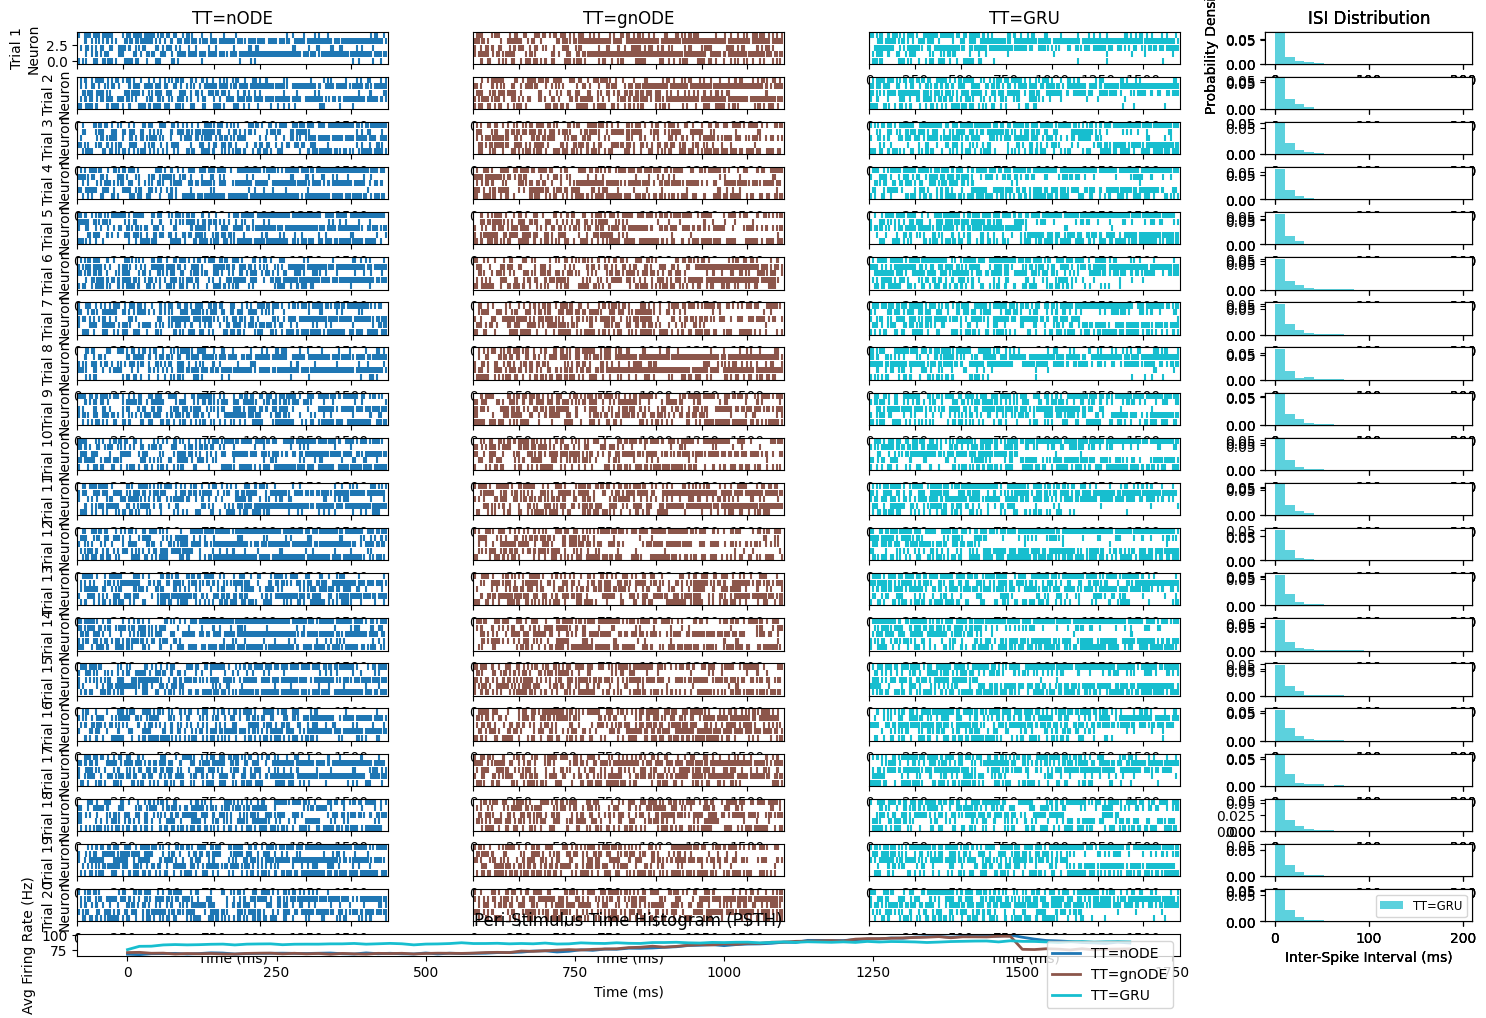

In [57]:
# Comprehensive comparison with all analysis
fig2 = compare_raster_plots([spike_data_node, spike_data_gnode, spike_data_gru],
                    [inputs_node, inputs_gnode, inputs_gru],
                    labels=['TT=nODE', 'TT=gnODE', 'TT=GRU'],
                     neurons_to_plot=5,
                     n_trials_to_plot=20)

# this i did NOT use


# all neurons have the same sudden change for ONE trial
# it varies across trials

# ex below for 10 neurons from first 3 trials (as many trials as input trials in TT)

In [52]:
def compare_raster_plots(spike_data_list, input_data_list, labels=None, 
                        n_trials_to_plot=10, neurons_to_plot=3, 
                        figsize=(18, 12), dt_ms=10, 
                        share_axes=True):
    """
    Create comparative raster plots of multiple neuronal activity datasets with corresponding
    PSTH (Peri-Stimulus Time Histogram) and ISI (Inter-Spike Interval) plots.
    
    Parameters:
    -----------
    spike_data_list : list of numpy.ndarray
        List of arrays, each with shape (n_trials, timesteps, n_neurons) containing spike data
    input_data_list : list of numpy.ndarray
        List of arrays, each with shape (n_trials, timesteps, input_dim) containing input signals
        (needed for time dimensions, but not plotted)
    labels : list of str or None
        Labels for each dataset (for legend and titles)
    n_trials_to_plot : int or None
        Number of trials to plot. If None, all trials are plotted.
    neurons_to_plot : int
        Number of neurons to plot (from the beginning of the array)
    figsize : tuple
        Figure size (width, height) in inches
    dt_ms : float
        Time bin size in milliseconds (for proper time axis scaling)
    share_axes : bool
        Whether to share axes across datasets for direct comparison
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    
    n_datasets = len(spike_data_list)
    if labels is None:
        labels = [f'Dataset {i+1}' for i in range(n_datasets)]
    elif len(labels) != n_datasets:
        raise ValueError("Length of labels must match length of spike_data_list")
    
    # Get basic shape information from first dataset
    n_trials, timesteps, n_neurons = spike_data_list[0].shape
    
    # Handle how many trials to plot
    if n_trials_to_plot is None:
        n_trials_to_plot = n_trials
    else:
        n_trials_to_plot = min(n_trials_to_plot, n_trials)
    
    # Handle how many neurons to plot
    neurons_to_plot = min(neurons_to_plot, n_neurons)
    
    # Fixed layout: raster plot, PSTH (only for first trial), and ISI
    rows_per_trial = 1  # Only raster plot per trial
    
    # Create figure with GridSpec for flexible subplot layout
    fig = plt.figure(figsize=figsize)
    
    # Create a grid for raster plots + PSTH + ISI 
    ncols = n_datasets + 1  # Add column for ISI plots
    width_ratios = [3] * n_datasets + [2]  # Main plots take more space
    
    # Set up height ratios: One row per trial for raster + one row for PSTH
    height_ratios = [3] * n_trials_to_plot + [2]  # Raster plots + PSTH
    
    gs = gridspec.GridSpec(n_trials_to_plot + 1, ncols, 
                          height_ratios=height_ratios,
                          width_ratios=width_ratios)
    
    # Color scheme for different datasets
    colors = plt.cm.tab10(np.linspace(0, 1, n_datasets))
    
    # Create shared axes if requested
    shared_raster_ax = None
    
    # Store the axes for proper labeling later
    axes_dict = {
        'raster': [],
        'psth': None,
        'isi': []
    }
    
#     ax_isi = fig.add_subplot(gs[row_offset, -1])
#     axes_dict['isi'].append(ax_isi)
    
    # Plot each trial
    for trial_idx in range(n_trials_to_plot):
        row_offset = trial_idx  # One row per trial
        
        # Plot all datasets in columns
        for dataset_idx, spike_data in enumerate(spike_data_list):
            
            # Create subplot for spike data (raster plot)
            if share_axes and shared_raster_ax is not None and trial_idx > 0:
                ax_spikes = fig.add_subplot(gs[row_offset, dataset_idx], sharex=shared_raster_ax, sharey=shared_raster_ax)
            else:
                ax_spikes = fig.add_subplot(gs[row_offset, dataset_idx])
                if trial_idx == 0 and share_axes:
                    shared_raster_ax = ax_spikes
            axes_dict['raster'].append(ax_spikes)
            
            # Plot spike raster
            for neuron_idx in range(neurons_to_plot):
                spike_times = np.where(spike_data[trial_idx, :, neuron_idx] > 0)[0]
                ax_spikes.scatter(spike_times, [neuron_idx] * len(spike_times), 
                               marker='|', color=colors[dataset_idx], s=20)
            
            # Configure raster plot aesthetics
            ax_spikes.set_ylim(-0.5, neurons_to_plot - 0.5)
            ax_spikes.set_xlim(0, timesteps)
            if dataset_idx == 0:
                ax_spikes.set_ylabel(f'Trial {trial_idx+1}\nNeuron')
            else:
                ax_spikes.set_yticks([])
            
            if trial_idx == 0:
                ax_spikes.set_title(labels[dataset_idx])
            
            # Hide x-ticks except for bottom plot
            if trial_idx < n_trials_to_plot - 1:
                ax_spikes.set_xticklabels([])
            
            # Add ISI plot in the last column
# #             if dataset_idx == n_datasets - 1:
#             ax_isi = fig.add_subplot(gs[row_offset, -1])
#             axes_dict['isi'].append(ax_isi)

            ax_isi = fig.add_subplot(gs[row_offset, -1])
            axes_dict['isi'].append(ax_isi)
            
            # Calculate and plot ISI histograms
            bins = np.linspace(0, 200, 20)  # 0-200 ms bins
            
            trial_spike_data = spike_data[trial_idx, :, :neurons_to_plot]
            
            # Combine ISIs across all plotted neurons
            all_isi = []
            for neuron_idx in range(neurons_to_plot):
                spike_times = np.where(trial_spike_data[:, neuron_idx] > 0)[0] * dt_ms
                if len(spike_times) > 1:
                    all_isi.extend(np.diff(spike_times))
            
            if len(all_isi) > 0:
                ax_isi.hist(all_isi, bins=bins, alpha=0.7, 
                           color=colors[dataset_idx],
                           label=labels[dataset_idx], density=True)
            
            ax_isi.set_xlabel('Inter-Spike Interval (ms)')
            if trial_idx == 0:
                ax_isi.set_ylabel('Probability Density')
                ax_isi.set_title('ISI Distribution')
        
    # Add PSTH plot at the bottom spanning all dataset columns
    ax_psth = fig.add_subplot(gs[-1, :n_datasets])
    axes_dict['psth'] = ax_psth
    
    # Calculate PSTH across all trials for each dataset
    psth_bin_size = int(20/dt_ms)  # 20 ms bins
    n_bins = timesteps // psth_bin_size
    time_axis_psth = (np.arange(n_bins) * psth_bin_size) * dt_ms
    
    # Create a single plot with all datasets overlaid
    for dataset_idx, spike_data in enumerate(spike_data_list):
        psth = np.zeros((n_bins, neurons_to_plot))
        
        for bin_idx in range(n_bins):
            start = bin_idx * psth_bin_size
            end = start + psth_bin_size
            if end <= timesteps:
                psth[bin_idx] = np.mean(spike_data[:, start:end, :neurons_to_plot], 
                                     axis=(0,1)) * (1000/dt_ms)
        
        # Plot average PSTH across neurons
        avg_psth = np.mean(psth, axis=1)
        ax_psth.plot(time_axis_psth, avg_psth, color=colors[dataset_idx], 
                   label=labels[dataset_idx], linewidth=2)
    
    ax_psth.set_ylabel('Avg Firing Rate (Hz)')
    ax_psth.set_xlabel('Time (ms)')
    ax_psth.set_title('Peri-Stimulus Time Histogram (PSTH)')
    ax_psth.legend(loc='upper right')
    
    # Add proper time axis labels for bottom raster plots and PSTH
    # For the bottom row of raster plots
    for dataset_idx in range(n_datasets):
        idx = n_trials_to_plot * n_datasets - (n_datasets - dataset_idx)
        if idx >= 0 and idx < len(axes_dict['raster']):
            ax = axes_dict['raster'][idx]
            xticks = ax.get_xticks()
            ax.set_xticklabels([f'{int(x*dt_ms)}' for x in xticks])
            ax.set_xlabel('Time (ms)')
    
    # For the PSTH plot
    xticks = ax_psth.get_xticks()
    ax_psth.set_xticklabels([f'{int(x)}' for x in xticks])
    
    # Add a combined legend for ISI plots in the last column
    if len(axes_dict['isi']) > 0:
        last_isi_ax = axes_dict['isi'][-1]
        handles, labels_list = last_isi_ax.get_legend_handles_labels()
        if handles:
            last_isi_ax.legend(fontsize='small')
    
    # Adjust spacing between subplots
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.tight_layout()
    
    return fig